In [3]:
# importing dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# loading all submissions dataframes
submission01 = pd.read_csv('https://raw.githubusercontent.com/atharv-d21/traffic_demand_prediction/refs/heads/main/submissions/submission01.csv')

submission02 = pd.read_csv('https://raw.githubusercontent.com/atharv-d21/traffic_demand_prediction/refs/heads/main/submissions/submission02.csv')

submission03 = pd.read_csv('https://raw.githubusercontent.com/atharv-d21/traffic_demand_prediction/refs/heads/main/submissions/submission03.csv')

submission04 = pd.read_csv('https://raw.githubusercontent.com/atharv-d21/traffic_demand_prediction/refs/heads/main/submissions/submission04.csv')

submission05 = pd.read_csv('https://raw.githubusercontent.com/atharv-d21/traffic_demand_prediction/refs/heads/main/submissions/submission05.csv')

submission06 = pd.read_csv('https://raw.githubusercontent.com/atharv-d21/traffic_demand_prediction/refs/heads/main/submissions/submission06.csv')

submission07 = pd.read_csv('https://raw.githubusercontent.com/atharv-d21/traffic_demand_prediction/refs/heads/main/submissions/submission07.csv')

submission01.head(5)

,Index,demand
0,0,0.051684
1,1,0.061896
2,2,0.034261
3,3,0.029549
4,4,0.054078


In [5]:
combined_df = submission01.rename(columns={'demand': 'submission01'})

for i, df in enumerate([submission02, submission03, submission04, submission05, submission06, submission07], start=2):
    col_name = f'submission{i:02d}'
    temp_df = df.rename(columns={'demand': col_name})
    combined_df = pd.merge(combined_df, temp_df, on='Index', how='outer')

display(combined_df.head())

,Index,submission01,submission02,submission03,submission04,submission05,submission06,submission07
0,0,0.051684,0.056390,0.084289,0.051153,0.039667,0.043983,0.041825
1,1,0.061896,0.061805,0.064654,0.029562,0.019780,-0.004964,0.007408
2,2,0.034261,0.039460,0.062760,0.009010,0.048068,0.008922,0.028495
3,3,0.029549,0.037228,0.059765,0.012022,0.024480,-0.011005,0.006737
4,4,0.054078,0.053735,0.063295,0.048343,0.048819,0.006338,0.027579


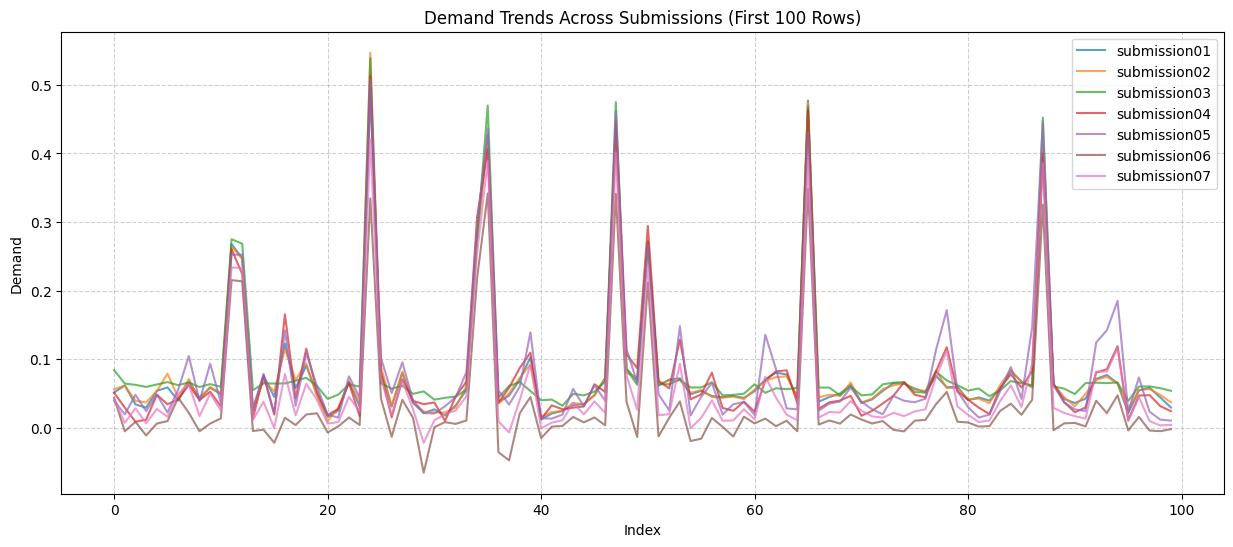

In [6]:
plt.figure(figsize=(15, 6))
for col in ['submission01', 'submission02', 'submission03', 'submission04', 'submission05', 'submission06', 'submission07']:
    plt.plot(combined_df['Index'][:100], combined_df[col][:100], label=col, alpha=0.7)

plt.title('Demand Trends Across Submissions (First 100 Rows)')
plt.xlabel('Index')
plt.ylabel('Demand')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [7]:
# Calculate the correlation matrix for the submission columns
submission_cols = ['submission01', 'submission02', 'submission03', 'submission04', 'submission05', 'submission06', 'submission07']
correlation_matrix = combined_df[submission_cols].corr()

# Display the correlation matrix
display(correlation_matrix)

,submission01,submission02,submission03,submission04,submission05,submission06,submission07
submission01,1.000000,0.997279,0.982064,0.991446,0.982616,0.921291,0.979882
submission02,0.997279,1.000000,0.985611,0.991868,0.981681,0.923275,0.980103
submission03,0.982064,0.985611,1.000000,0.977396,0.958518,0.941654,0.973163
submission04,0.991446,0.991868,0.977396,1.000000,0.984041,0.913611,0.977670
submission05,0.982616,0.981681,0.958518,0.984041,1.000000,0.909381,0.985850
submission06,0.921291,0.923275,0.941654,0.913611,0.909381,1.000000,0.966242
submission07,0.979882,0.980103,0.973163,0.977670,0.985850,0.966242,1.000000


In [8]:
combined_df['demand'] = (combined_df['submission05'] + combined_df['submission07']) / 2

display(combined_df[['Index', 'submission05', 'submission07', 'demand']].head())

,Index,submission05,submission07,demand
0,0,0.039667,0.041825,0.040746
1,1,0.019780,0.007408,0.013594
2,2,0.048068,0.028495,0.038281
3,3,0.024480,0.006737,0.015609
4,4,0.048819,0.027579,0.038199
